In [1]:
# ch04_PROJECT.ipynb

In [ ]:
!pip install matplotlib 

  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
Using cached beautifulsoup4-4.14.3-py3-none-any.whl (107 kB)

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# macOS / Linux / Windows에 맞는 폰트 선택
# macOS: AppleGothic
# Windows: Malgun Gothic
# Linux(Colab 등): NanumGothic (사전 설치 필요)

plt.rcParams['font.family'] = 'AppleGothic'  # macOS
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'NanumGothic'  # Linux

# 마이너스 기호 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False


In [15]:
# 멀티 에이전트로 경제 데이터 시각화

In [16]:
from typing import Annotated
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model

llm = init_chat_model("openai:gpt-4.1")

# 1) 검색 도구 (Tavily API 필요)
tavily_tool = TavilySearch(max_results=5)

# 2) 로컬 파이썬 실행 도구 (차트 생성 전용)
repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "차트를 생성하기 위한 파이썬 코드"]
):
    """파이썬 코드를 실행합니다. 출력은 print(...)로 표시해야 합니다."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"실행 실패: {repr(e)}"
    return f"성공적으로 실행했습니다:\n```python\n{code}\n```\nStdout: {result}\n\nFINAL ANSWER"


In [17]:
# 3) 시스템 프롬프트 템플릿
def make_system_prompt(suffix: str):
    return (
        "당신은 다른 어시스턴트와 협업하는 유능한 AI입니다. "
        "주어진 도구만 사용해 작업을 완수하세요. "
        "최종 답변을 얻으면 반드시 'FINAL ANSWER'를 붙여 종료하세요."
        f"\n{suffix}"
    )

def get_next_node(last_message: BaseMessage, goto: str):
    if "FINAL ANSWER" in last_message.content:
        return END
    return goto

In [18]:
from typing import Literal
from langchain.agents import create_agent 
from langgraph.graph import MessagesState
from langgraph.types import Command

# 4) 리서처 노드 (검색 전용)
research_agent = create_agent(
    model=llm,
    tools=[tavily_tool],
    system_prompt=make_system_prompt("당신은 리서치만 할 수 있습니다. 동료 차트 생성자와 협업하세요.")
)

def research_node(state: MessagesState) -> Command[Literal["chart_generator", END]]:
    result = research_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "chart_generator")
    # 일부 모델/프로바이더 제약 회피: 마지막 메시지를 Human 역할로 래핑
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="researcher")
    return Command(update={"messages": result["messages"]}, goto=goto)

# 5) 차트 생성 노드 (파이썬 실행 전용)
chart_agent = create_agent(
    model=llm,
    tools=[python_repl_tool],
    system_prompt=make_system_prompt("당신은 차트 생성만 할 수 있습니다. 동료 리서처와 협업하세요.")
)

def chart_node(state: MessagesState) -> Command[Literal["researcher", END]]:
    result = chart_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "researcher")
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="chart_generator")
    return Command(update={"messages": result["messages"]}, goto=goto)


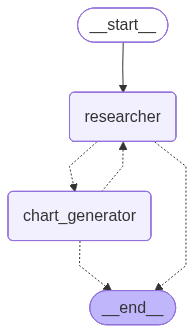

In [19]:
from IPython.display import Image, display

# 6) 그래프 구성
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)
workflow.add_edge(START, "researcher")  # 리서처부터 시작
graph = workflow.compile()

# 다이어그램 표시
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


{'researcher': {'messages': [HumanMessage(content='지난 1년간 달러 환율 데이터를 조사하고, 그 데이터를 기반으로 라인 차트를 만드세요.차트를 생성했으면 작업을 종료하세요.', additional_kwargs={}, response_metadata={}, id='9ae3a0be-e90d-4977-bd47-c68fb0b9306d'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 1295, 'total_tokens': 1325, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_1a2c4a5ede', 'id': 'chatcmpl-CzNLesGoAyTBkCJbqMt9npkeeK507', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019bd158-7618-7ad0-9936-d5c9e0043a33-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '달러 환율 지난 1년간 데이터', 'search_depth': 'advanced'}, 'id': 'call_KhMNwARN8h47pueb7yy2HB

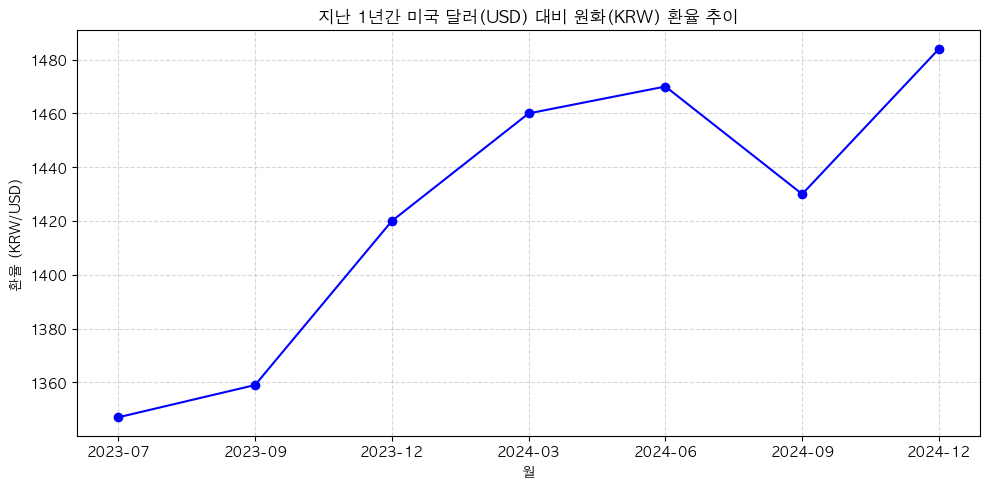

{'chart_generator': {'messages': [HumanMessage(content='지난 1년간 달러 환율 데이터를 조사하고, 그 데이터를 기반으로 라인 차트를 만드세요.차트를 생성했으면 작업을 종료하세요.', additional_kwargs={}, response_metadata={}, id='9ae3a0be-e90d-4977-bd47-c68fb0b9306d'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 1295, 'total_tokens': 1325, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_1a2c4a5ede', 'id': 'chatcmpl-CzNLesGoAyTBkCJbqMt9npkeeK507', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019bd158-7618-7ad0-9936-d5c9e0043a33-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '달러 환율 지난 1년간 데이터', 'search_depth': 'advanced'}, 'id': 'call_KhMNwARN8h47pueb7

In [20]:
# 7) 실행
events = graph.stream(
    {
        "messages": [(
            "user",
            "지난 1년간 달러 환율 데이터를 조사하고, 그 데이터를 기반으로 라인 차트를 만드세요."
            "차트를 생성했으면 작업을 종료하세요."
        )]
    },
    {"recursion_limit": 150}  # 안전장치: 최대 스텝 제한
)

for step in events:
    print(step)   # 각 단계의 중간 결과/메시지 스트림 확인
    print("----")


In [ ]:
# 멀티 에이전트로 경제 데이터 보고서 작성

In [ ]:
!pip install beautifulsoup4

In [21]:
from __future__ import annotations
from typing import Annotated, List, Dict, Optional, Literal
from typing_extensions import TypedDict


from pathlib import Path

from pydantic import BaseModel, Field

# LangGraph
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import Command

# LangChain
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage, BaseMessage, SystemMessage
from langchain_core.tools import tool

# Tools
from langchain_tavily import TavilySearch
from langchain_community.document_loaders import WebBaseLoader
from langchain_experimental.utilities import PythonREPL


# 1) 공용 상태 정의
class State(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    next: str
    
# 2) 리서치팀 도구
# Tavily 웹 검색: 상위 n개 결과를 반환
tavily_tool = TavilySearch(max_results=5)

@tool
def scrape_webpages(urls: List[str]):
    """요청한 웹 페이지 목록을 크롤링하여 본문 텍스트를 추출합니다."""
    loader = WebBaseLoader(
        urls,
        header_template={
            "User-Agent": (
                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/122.0.0.0 Safari/537.36"
            )})
    docs = loader.load()
    return "\n\n".join(
        [
            f'<문서 제목="{doc.metadata.get("title", "")}">\n{doc.page_content}\n</문서>'
            for doc in docs
        ]
    )

In [ ]:
# 3) 문서팀 도구
WORKING_DIRECTORY = Path.cwd() 

@tool
def create_outline(
    points: Annotated[List[str], "섹션/소제목 리스트"],
    file_name: Annotated[str, "개요를 저장할 파일 경로(상대/절대)"]):
    """개요(아웃라인)를 파일로 저장합니다."""
    path = (WORKING_DIRECTORY / file_name)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        for i, p in enumerate(points):
            f.write(f"{i + 1}. {p}\n")
    return f"개요 저장 완료: {path}"

@tool
def read_document(
    file_name: Annotated[str, "읽을 파일 경로"],
    start: Annotated[Optional[int], "시작 줄(기본 0)"] = None,
    end: Annotated[Optional[int], "끝 줄(기본 None)"] = None):
    """지정한 텍스트 문서를 읽어 반환합니다(부분 범위 가능)."""
    path = (WORKING_DIRECTORY / file_name)
    with path.open("r", encoding="utf-8") as f:
        lines = f.readlines()
    start = 0 if start is None else start
    return "".join(lines[start:end])

@tool
def write_document(
    content: Annotated[str, "파일에 저장할 텍스트 콘텐츠"],
    file_name: Annotated[str, "저장할 파일 경로"]):
    """텍스트 문서를 새로 작성/덮어씁니다."""
    path = (WORKING_DIRECTORY / file_name)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        f.write(content)
    return f"문서 저장 완료: {path}"

@tool
def edit_document(
    file_name: Annotated[str, "수정할 파일 경로"],
    inserts: Annotated[
        Dict[int, str],
        "삽입할 위치(1부터 시작)와 텍스트의 딕셔너리",
    ]):
    """지정한 줄 번호 위치에 문장을 삽입합니다."""
    path = (WORKING_DIRECTORY / file_name)
    with path.open("r", encoding="utf-8") as f:
        lines = f.readlines()

    for line_no, text in sorted(inserts.items()):
        if 1 <= line_no <= len(lines) + 1:
            lines.insert(line_no - 1, text + "\n")
        else:
            return f"오류: 줄 번호 {line_no} 범위를 벗어났습니다."

    with path.open("w", encoding="utf-8") as f:
        f.writelines(lines)
    return f"문서 수정/저장 완료: {path}"

# 로컬 파이썬 실행(차트 등)
repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "차트 생성 등 실행할 파이썬 코드(출력은 print로 표시)"],
):
    """파이썬 코드를 실행합니다. 결과를 보려면 print(...)를 사용하세요."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"실행 실패: {repr(e)}"
    return f"성공적으로 실행했습니다:\n```python\n{code}\n```\nStdout: {result}"



In [25]:
# 4) "감독자(supervisor)" 노드 팩토리
#    - 멤버 이름 목록을 받아, 다음에 호출할 워커를 LLM이 결정
#    - Pydantic 스키마로 구조화된 출력 사용
def make_supervisor_node(llm, members: List[str]):
    options = ["FINISH", *members]

    system_prompt = (
        "당신은 다음 워커들을 관리하는 감독자입니다: "
        f"{members}. "
        "사용자 요청과 현재까지의 대화 메시지를 보고 "
        "다음에 실행할 워커를 한 명만 선택하세요. "
        "모든 작업이 끝났다면 FINISH를 선택하세요."
    )

    class Router(BaseModel):
        next: Literal[*options] = Field(..., description="다음 노드명 또는 FINISH")

    def supervisor_node(state: State):
        messages = [SystemMessage(content=system_prompt)] + state["messages"]
        decision = llm.with_structured_output(Router).invoke(messages)
        # 라우팅은 그래프(add_conditional_edges)가 수행 → 여기서는 next만 저장
        return {"next": decision.next}

    return supervisor_node

In [10]:

# 5) 리서치팀 (검색 + 스크래핑) 서브그래프
search_agent = create_agent(llm, tools=[tavily_tool])

def search_node(state: State) -> Command[Literal["supervisor"]]:
    """검색 워커: 질의 → 검색 결과 요약"""
    result = search_agent.invoke(state)
    return Command(
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="search")]},
        goto="supervisor",
    )

web_scraper_agent = create_agent(llm, tools=[scrape_webpages])

def web_scraper_node(state: State) -> Command[Literal["supervisor"]]:
    """스크래핑 워커: URL들 → 본문 추출"""
    result = web_scraper_agent.invoke(state)
    return Command(
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="web_scraper")]},
        goto="supervisor",
    )

research_supervisor_node = make_supervisor_node(llm, ["search", "web_scraper"])

# 리서치팀 그래프
def route_from_supervisor(state) -> str:
    # supervisor가 update로 저장한 값 이용
    nxt = state.get("next", "")
    if nxt == "FINISH":
        return END
    return nxt  # "search" 또는 "web_scraper"

research_builder = StateGraph(State)
research_builder.add_node("supervisor", research_supervisor_node)
research_builder.add_node("search", search_node)
research_builder.add_node("web_scraper", web_scraper_node)

research_builder.add_edge(START, "supervisor")
research_builder.add_conditional_edges(
    "supervisor",
    route_from_supervisor,
    {
        "search": "search",
        "web_scraper": "web_scraper",
        END: END,
    },
)

research_graph = research_builder.compile()

In [11]:
# 6) 문서팀 (개요/작성/차트) 서브그래프
note_taking_agent = create_agent(
    llm,
    tools=[create_outline, read_document],
    system_prompt="당신은 문서 개요를 만드는 어시스턴트입니다. 추가 질문 없이 개요를 작성하세요."
)

def note_taking_node(state: State) -> Command[Literal["supervisor"]]:
    """노트테이커: 개요 작성/읽기"""
    result = note_taking_agent.invoke(state)
    return Command(
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="note_taker")]},
        goto="supervisor",
    )

doc_writer_agent = create_agent(
    llm,
    tools=[write_document, edit_document, read_document],
    system_prompt="당신은 개요를 바탕으로 초안을 작성/수정하는 문서 작성기입니다. 추가 질문 없이 바로 수행하세요."
)

def doc_writing_node(state: State) -> Command[Literal["supervisor"]]:
    """문서 작성자: 초안 작성/수정"""
    result = doc_writer_agent.invoke(state)
    return Command(
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="doc_writer")]},
        goto="supervisor",
    )

chart_generating_agent = create_agent(
    llm,
    tools=[read_document, python_repl_tool],
    system_prompt="당신은 파이썬 코드를 실행해 차트를 생성/저장하는 작업을 담당합니다."
)

def chart_generating_node(state: State) -> Command[Literal["supervisor"]]:
    """차트 생성자: 파이썬 실행(차트)"""
    result = chart_generating_agent.invoke(state)
    return Command(
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="chart_generator")]},
        goto="supervisor",
    )

doc_writing_supervisor_node = make_supervisor_node(
    llm, ["note_taker", "doc_writer", "chart_generator"]
)

# 문서팀 그래프
paper_writing_builder = StateGraph(State)
paper_writing_builder.add_node("supervisor", doc_writing_supervisor_node)
paper_writing_builder.add_node("note_taker", note_taking_node)
paper_writing_builder.add_node("doc_writer", doc_writing_node)
paper_writing_builder.add_node("chart_generator", chart_generating_node)

paper_writing_builder.add_edge(START, "supervisor")
paper_writing_builder.add_conditional_edges(
    "supervisor",
    route_from_supervisor,
    {
        "note_taker": "note_taker",
        "doc_writer": "doc_writer",
        "chart_generator": "chart_generator",
        END: END,
    },
)
paper_writing_graph = paper_writing_builder.compile()


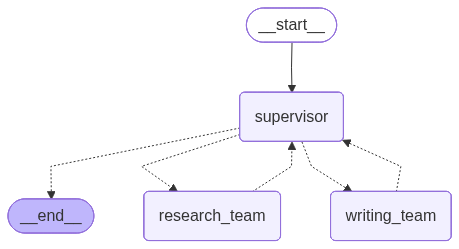

In [ ]:
# 7) 최상위 그래프 (팀 간 오케스트레이션)
top_supervisor_node = make_supervisor_node(llm, ["research_team", "writing_team"])

def call_research_team(state: State) -> Command[Literal["supervisor"]]:
    """리서치팀 서브그래프 호출"""
    # 마지막 메시지만 넘겨도 되지만, 필요하다면 전체 state["messages"]를 넘기는 설계로 바꿀 수 있음
    response = research_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update={"messages": [HumanMessage(content=response["messages"][-1].content, name="research_team")]},
        goto="supervisor",
    )

def call_paper_writing_team(state: State) -> Command[Literal["supervisor"]]:
    """문서팀 서브그래프 호출"""
    response = paper_writing_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update={"messages": [HumanMessage(content=response["messages"][-1].content, name="writing_team")]},
        goto="supervisor",
    )

# 최상위 그래프
super_builder = StateGraph(State)
super_builder.add_node("supervisor", top_supervisor_node)
super_builder.add_node("research_team", call_research_team)
super_builder.add_node("writing_team", call_paper_writing_team)

super_builder.add_edge(START, "supervisor")
super_builder.add_conditional_edges(
    "supervisor",
    route_from_supervisor,
    {
        "research_team": "research_team",
        "writing_team": "writing_team",
        END: END,
    },
)
super_graph = super_builder.compile()

# 다이어그램 표시
try:
    display(Image(super_graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


=== 실행 예시: '환율' 간단 리포트 생성 ===
{'supervisor': {'next': 'research_team'}}
---
{'research_team': {'messages': [HumanMessage(content='아래의 파이썬 코드로 최근 1년(2023.06~2024.06) 동안의 원/달러 환율 데이터를 라인차트로 시각화하고, 이미지를 저장하겠습니다.\n\n```python\nimport matplotlib.pyplot as plt\n\ndates = ["2023-06", "2023-07", "2023-08", "2023-09", "2023-10", "2023-11", "2023-12", "2024-01", "2024-02", "2024-03", "2024-04", "2024-05", "2024-06"]\nrates = [1287, 1305, 1320, 1338, 1356, 1302, 1288, 1335, 1377, 1399, 1382, 1360, 1439]\n\nplt.figure(figsize=(10,5))\nplt.plot(dates, rates, marker=\'o\', linestyle=\'-\', color=\'b\')\nplt.title("최근 1년간 원/달러 환율 추이 (2023.06~2024.06)")\nplt.xlabel("날짜")\nplt.ylabel("환율 (원/USD)")\nplt.xticks(rotation=45)\nplt.grid(True)\nplt.tight_layout()\nplt.savefig("usd_krw_rate_2023-2024.png")\nplt.show()\n```\n\n위 코드를 실행하여 이미지를 생성한 후, 데이터 분석과 함께 마크다운 수형의 짧은 보고서를 작성하겠습니다. 지금 코드를 실행합니다.\n다음과 같이 코드를 실행하여 달러 환율 라인차트를 그리고 이미지를 저장하겠습니다. 이후, 데이터 분석 보고서도 함께 작성하겠습니다.', additional_kwargs={}, response_meta

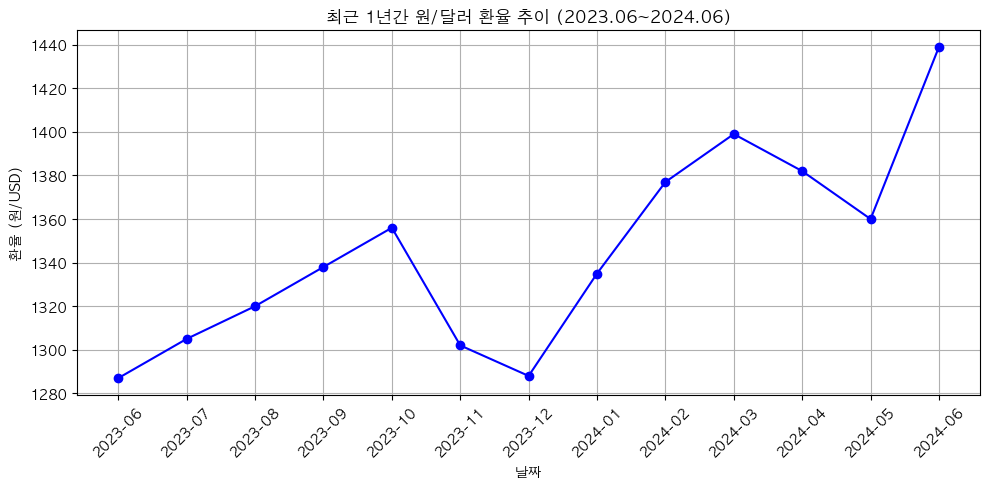

{'writing_team': {'messages': [HumanMessage(content='아래와 같이 마크다운 보고서가 "usd_krw_rate_analysis_report.md" 파일로 저장되었습니다.\n\n---\n\n## 최근 1년간 원/달러 환율 추이 분석 (2023.06 ~ 2024.06)\n\n![원/달러 환율 추이](usd_krw_rate_2023-2024.png)\n\n### 데이터 요약\n- 기간: 2023년 6월 ~ 2024년 6월 (13개월)\n- 최고 환율: 2024년 6월, 1,439원/USD\n- 최저 환율: 2023년 6월, 1,287원/USD\n\n### 주요 특징 및 해석\n- 구간 초반(2023년 하반기)에는 소폭 상승/하락이 반복되며 대체로 1,300~1,350원대에서 등락.\n- 2023년 11월과 12월에는 환율이 하락세(1,302→1,288)로 진입.\n- 2024년 1월 이후 뚜렷한 상승세가 관찰됨: 2024년 2월 1,377원, 2024년 3월 1,399원 기록.\n- 2024년 6월에 최고점인 1,439원을 기록하며, 최근 한 달 사이 급격한 상승.\n\n### 결론\n최근 1년 동안 원/달러 환율은 변동성이 비교적 높은 흐름을 보였습니다. 특히 2024년 상반기 이후 뚜렷한 상승세가 감지되며, 거시경제적 변수(미국 금리, 글로벌 경기 등)와 관련하여 환율 리스크에 주의가 필요한 시점으로 판단됩니다.', additional_kwargs={}, response_metadata={}, name='writing_team', id='fde0ac34-b6ba-47ba-8d64-0ff6336f75d5')]}}
---
{'supervisor': {'next': 'FINISH'}}
---

작업 디렉터리: /Users/gyungah/Jupyter/agent_Book/book/Ch04


In [13]:
# 8) 사용 예시 (스트림 실행)
print("=== 실행 예시: '환율' 간단 리포트 생성 ===")
events = super_graph.stream(
    {"messages": [("user", "1)최근 1년의 달러 환율을 인터넷에서 조사하고 2) python_repl_tool로 달러 환율을 라인차트를 그린 후 저장해주고 3) 짧은 보고서를 markdown 형태로 작성해 주세요.")]},
    {"recursion_limit": 150},
)
for step in events:
    print(step)
    print("---")

print("\n작업 디렉터리:", WORKING_DIRECTORY)
